# Mathematical Modelling


In [1]:
# Import the usual suspects for data manipulation, statistics, and visualisations.
import pandas as pd # used to "tidy" up and manipulate our data
import numpy as np # used for matrix and numerical calculations; foundation of pandas
from scipy import stats # contains stats functions and is used to visualise probability distributions
import matplotlib.pyplot as plt # used for visualisations
import seaborn as sns # a more user-friendly library used for visualisations

# Probability and distributions

So far we have only looked at ways to describe data with statistics, however it is not always desirable to simply collect and describe data from observations and experiments, sometimes there is a need to **predict** the outcome before an event has taken place. We have already spoken about the link between the **distribution** of our data and the **likelihood** of a data point being of a certain value - these two things are linked because the probability of an outcome is linked to relative frequency of that outcome in the observed data.






We can use observed data to build a mathematical model that aims to predict the **expected value** of a variable based on this fact. We won't always predict the outcome with certainty but we can get a feel for what is **likely** to occur.

Statistics would mean nothing to us without probabilities so it is important to have some basic understandings of probability theory. We'll delve into this more later but for now you should be happy with the following points:


* The probability that an event $A$ will happen is:

$$ P(A) = \frac{\text{number of outcomes that lead to that event}}{\text{total number of possible outcomes}} $$

* The relative frequency of an outcome in observed data will be given by:

$$\frac{\text{number of times an event happens in or data}}{\text{total number of data points}} $$

* In an unlimited experiment, e.g. rolling a dice infinite times, the relative frequency would equal the probability
* Probabilities are always between $0$ and $1$
* The probability of the event **not** occuring is $1 - P(A)$
* The **sample space** is the set of all possible outcomes for an event

## Key Probability Distributions

Looking at distributions is a bit like looking at the **shape** of our data by drawing a graph. However here the **shape** is not based on data, but on a **mathematical equation** that defines the distribution. Distributions are therefore **theoretical** but they are also useful as they describe patterns that we see occuring in real data.

- Because we can define a distribution mathematically we have the theoretical probabilities for all of the values that the variable could take

- These theoretical probabilities allow us to use the distributions as a **model** to predict the **expected value** that a variable might take

- They also allow us to decide **how likely** it is for a certain result to occur - more on this later

Where patterns commonly occur, mathematicians have names and defined several key distributions that can be applied to data analysis.

<font color='green'> 
    
### Activity

You will have covered visualisation of data and looked a little at the different shapes that data can make on a graph. The graphs below are generated by some theoretical distributions.

* what pattern do you notice? 
* which are the most common values? 
* where do you think the mean would lie?
* what can you tell about the probabilities of different values occuring?
* what type of variables do you think the distributions could describe? 
* can you think of any variables in real life that might follow this sort of pattern? </font>

In [2]:
# for inline plots in jupyter
%matplotlib inline
# import matplotlib
import matplotlib.pyplot as plt
# for latex equations
from IPython.display import Math, Latex
# for displaying images
from IPython.core.display import Image
# import seaborn
import seaborn as sns
# settings for seaborn plotting style
sns.set(color_codes=True)
# settings for seaborn plot sizes
sns.set(rc={'figure.figsize':(5,5)})

### Uniform Distribution 

[Text(0.5, 0, 'Uniform Distribution '), Text(0, 0.5, 'Relative Frequency')]

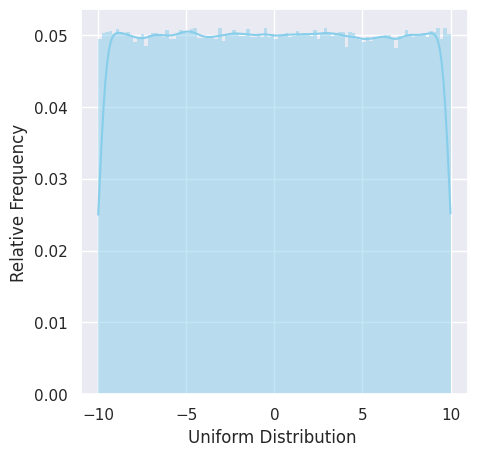

In [3]:

# import uniform distribution
from scipy.stats import uniform

# random numbers from uniform distribution
n = 1000000
start = -10
width = 20
data_uniform = uniform.rvs(size=n, loc = start, scale=width)

ax = sns.histplot(data_uniform,
                  bins=100,
                  kde=True,
                  color='skyblue',
                  stat="density", 
                  linewidth=0)
ax.set(xlabel='Uniform Distribution ', ylabel='Relative Frequency')


### Normal Distribution 

[Text(0.5, 0, 'Normal Distribution'), Text(0, 0.5, 'Relative Frequency')]

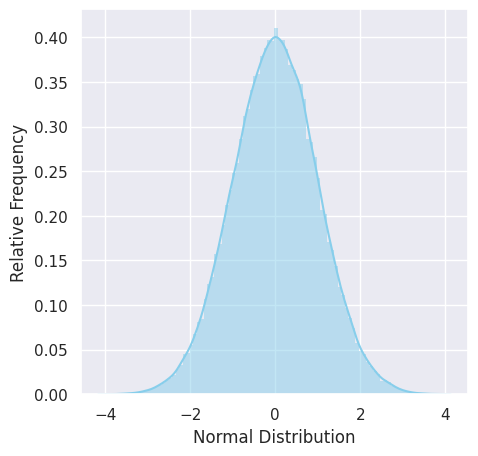

In [4]:

from scipy.stats import norm
# generate random numbers from N(0,1)
data_normal = norm.rvs(size=100000,loc=0,scale=1)

ax = sns.histplot(data_normal,
                  bins=100,
                  kde=True,
                  color='skyblue',
                  stat="density", 
                  linewidth=0)
ax.set(xlabel='Normal Distribution', ylabel='Relative Frequency')


### Exponential Decay 

[Text(0.5, 0, 'Exponential Distribution'), Text(0, 0.5, 'Relative Frequency')]

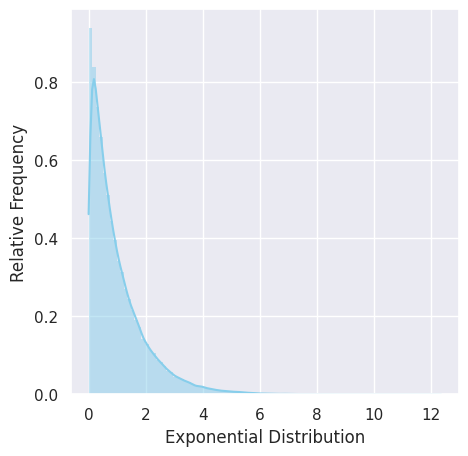

In [5]:

from scipy.stats import expon
data_expon = expon.rvs(scale=1,loc=0,size=100000)

ax = sns.histplot(data_expon,
                  kde=True,
                  bins=100,
                  color='skyblue', 
                  stat="density", 
                  linewidth=0)
ax.set(xlabel='Exponential Distribution', ylabel='Relative Frequency')

### Binomial Distribution 

[Text(0.5, 0, 'Binomial Distribution'), Text(0, 0.5, 'Relative Frequency')]

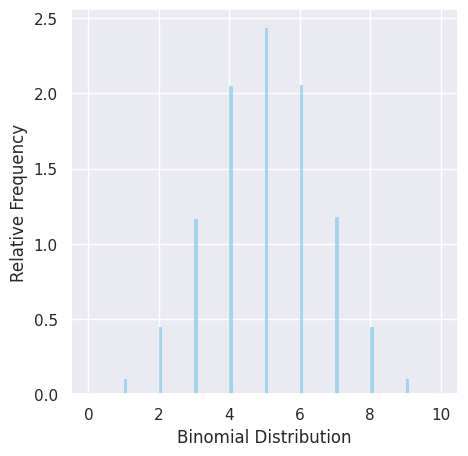

In [6]:

# sampling from the Binomial distribution
observations = stats.binom.rvs(n=10, p=0.5, size=100000)

ax = sns.histplot(observations,
                  bins=100,
                  kde=False,
                  color='skyblue',
                  stat="density", 
                  linewidth=0)
ax.set(xlabel='Binomial Distribution', ylabel='Relative Frequency')

### Poisson Distribution

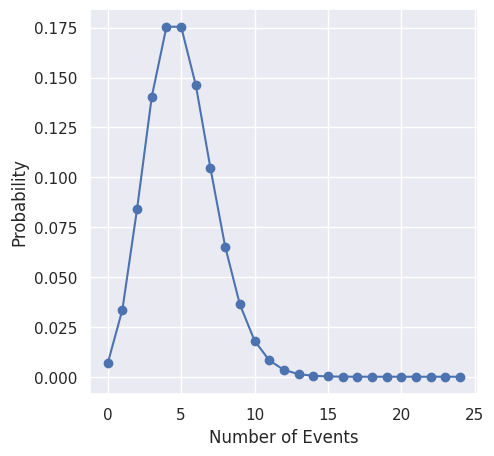

In [7]:

def poisson_plot(L):
    plt.figure()
    prob_k_successes = []
    for k in range(L * 5):
        prob_k_success = stats.poisson.pmf(k, L)
        prob_k_successes.append(prob_k_success)
    
    plt.plot(range(L * 5), prob_k_successes, '-o')
    
    plt.xlabel('Number of Events')
    plt.ylabel('Probability')   
    
    plt.show()

poisson_plot(5)

### Applications of key probability distributions

If we find during data analysis that our data appears to follow one of these familiar patterns, we can use the distribution as a **model**.

The variable values in the model are linked to probabilities which we can compute from the mathematical equation that defines the distribution. This allows us to work out the likelihood of certain outcomes in our model.

Therefore the application is in **predictive** analytics.

We will focus on applications of the **normal distribution** only in this module - more on this later.

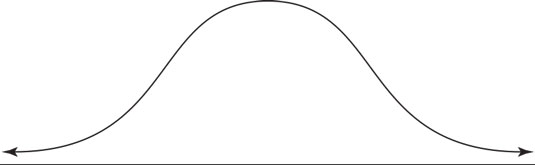

* Many times during data exploration plotting a histogram is the first step to understanding its distribution
* This can help us to identify if, for example, the data follows a well-known pattern e.g. the normal distribution



<Axes: xlabel='Height', ylabel='Count'>

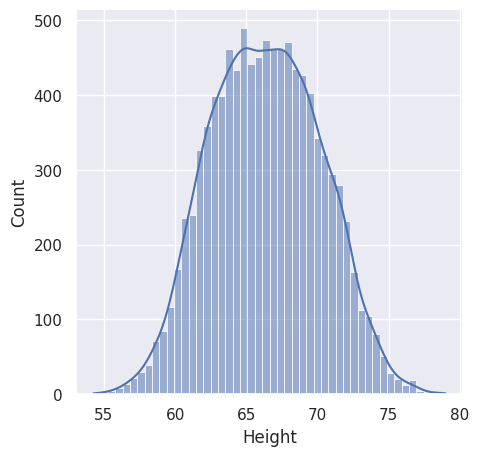

In [8]:
df = pd.read_csv("data/weight-height.csv")
sns.histplot(df.Height, kde=True)

## Bivariate data and correlation

So far we have only really been looking at one variable at a time when reviewing statistics and making predictions.

However, often we are interested in how different variables interact with each other.

When we study two variables at a time, we call this **bivariate** data analysis. You will already be familiar with this from the Data Visualisation module.

Often, one variable is **dependent** in some way on the other, that is, changes in variable 1 directly impact the value of variable 2. In the simplest possible scenario, this relationship is **linear**. This just means that based on the amount we increase or decrease variable 1 by, variable 2 changes **proportionately** to this amount. The scatter plot graph of the two variables would follow the shape of a **straight line**.


### Linear models

Remember a model is just a mathematical equation that describes the **shape** of a graph. If our scatter plot follows the pattern of a **straight line** we can represent this relationship mathematically. This then allows is to make **predictions** about the value of one variable based on another.

The usefulness of the predictions we can make from our linear model will depend on two key things:

1) The range of data used to generate the model (interpolation vs. extrapolation)

2) The strength of the linear relationship, which we refer to as the **correlation**




### Correlation
- Correlation describes the strength of the relationship (and the type of relationship) between two variables
- If correlation between two variables is strong, it follows that we can be more certain that our prediction will be close to the truth
- We can quantify correlation using a statistic called the **correlation coefficent**

### The correlation coefficient

We can measure the strength of correlation of two variables by calculating something that we call a "correlation coefficient" (usually referred to as "r"). The value of r can be between -1 and 1, and tells us something about the strength of the correlation. The stronger the correlation, the closer the value of r will be to either 1 or -1 which signify perfect positive or negative correlation.

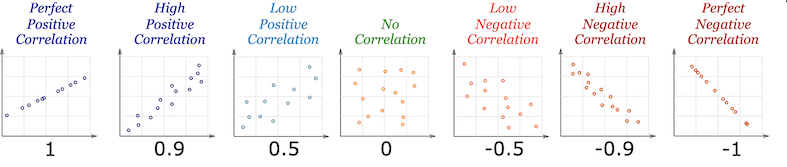

### Correlation $\neq$ Causation

It's important to remember that just because we can see correlation in our data, that it does not **neccessarily** imply causation.

There are many famous examples that illustrate this, for example:

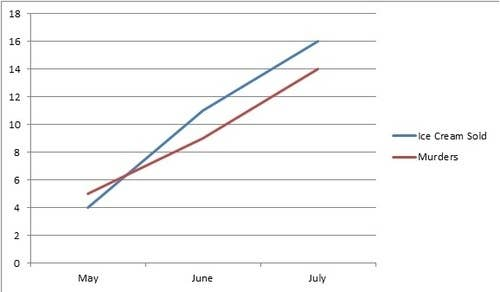

## Summary

In this section we have looked at different models:

- models for **univariate** data that explore patterns in one variable only
- models for **bivariate** data which seek to describe the **relationship** between two variables

You should: 

- understand what a mathematical distribution is and how they can be used to model a variable
- be aware of some commonly used distributions 
- know that we can model a linear relationship between variables with a straight line
- know how to use the correlation coefficient as an indication of the strength of a linear relationship
- understand that a model can produce results of varying reliability and apply a critical eye to conclusions drawn